In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pydftlj.dft import DFT

from ase.io import read

# Author: Elvis do A. Soares
# Github: @elvissoares
# Date: 2026-07-07

In [2]:
kB = 1.380649e-23 # J/K
Rconst = 0.082057366080960 # Gas constant
NA = 6.022e23 # Avogadro number

## Solid CIF file Information

In [3]:
structure_name = 'aCarbon-Bhatia-id001'
# Reading a CIF File
structure_filename = f'structures/'+structure_name+'.cif'
structure = read(structure_filename)

print('Structure name =', structure_name)
print('Number of atoms =', len(structure))
print( 'Chemical formula =', structure.get_chemical_formula())
print('Cell lengths =', structure.cell.lengths())
print('Cell angles =', structure.cell.angles())

Structure name = aCarbon-Bhatia-id001
Number of atoms = 1166
Chemical formula = C1166
Cell lengths = [29.5 29.8 30.2]
Cell angles = [90. 90. 90.]


Visualizing the solid structure in 3D

In [4]:
from ase.visualize import view

view(structure, viewer="x3d")

# Create the DFT object

In [5]:
system = DFT(functional='aWBI+MMFA')

## Fluid Information (CH4)

_References_:
- **TraPPE**: M.G. Martin, and J.I. Siepmann, J. Phys. Chem. B 102, 2569-2577 (1998).

In [6]:
fluid_molecule = 'CH4'

fluid_forcefield = 'TraPPE'
epsilonff = 148.0
sigmaff = 3.73
mff = 16.043

rcut = 14.0 # Angstrom

In [7]:
system.set_fluid_properties(sigma=sigmaff,epsilon=epsilonff,mass=mff,cut_off=rcut)

In [8]:
system.set_gridsize(gridsize=0.25*sigmaff)

In [9]:
system.set_geometry_from_ase(atoms=structure)

Geometry defined from ASE atoms object:
Lx=29.50 A, Ly=29.80 A, Lz=30.20 A
Unit cell Volume = 26548.82 A³
Solid Mass = 14004.83 u
Solid Mass Density = 0.5275 u/A³
Grid defined!
Lgrid = (np.float64(29.5), np.float64(29.8), np.float64(30.2))  A
X-axis = [ 0.0 , 29.5 ] A
Y-axis = [ 0.0 , 29.8 ] A
Z-axis = [ 0.0 , 30.2 ] A
Number of gridpoints = (32, 32, 33)
delta =  [0.9325 0.9325 0.9325]  A
Vol = 26548.82  A³


## Generating the External Potential from Solid Structure

In [10]:
forcefield_name = 'DREIDING'
system.calculate_external_potential_lj(forcefield_path='parameters/'+forcefield_name+'-forcefield.dat')

## Setting the Temperature

In [11]:
kT = 300.0 # kelvin (kB = 1)
system.set_temperature(kT)

In [12]:
print(f'Calculated pore volume for He atom @ T ={kT:.2f}K is {system.Vpore:.2f} A³')
print(f'Calculated He void fraction @ T ={kT:.2f}K is {system.helium_fraction:1.3f}')

Calculated pore volume for He atom @ T =300.00K is 19328.62 A³
Calculated He void fraction @ T =300.00K is 0.728


Exporting the external potential to a file `.cube` that can be visualized with softwares like VESTA ([https://jp-minerals.org/vesta/en/](https://jp-minerals.org/vesta/en/))

In [13]:
from ase.io.cube import write_cube

# Write to a cube file
with open(f"external_potential-{structure_name}.cube", 'w') as f:
    write_cube(f,structure,data=system.beta*system.Vext.cpu().numpy())

## Defining the Pressure range

The pressure values should be in bar

In [14]:
pbar_values = np.hstack((np.array([0.001,0.01]),np.arange(0.1,1.0,0.1),np.arange(1.,10,1.0),np.arange(10.,100,10.0),np.arange(100,200,20.0),np.arange(250,500,50.0),np.arange(500,1000,100.0))) # bulk pressure (in bar)

## Calculating isotherm

In [15]:
output_filename = f'isotherm_results-CH4-{structure_name}'

Calculating the whole isotherm and exporting density profiles at specified pressure values (in bar)

In [16]:
%%time

system.calculate_isotherm(pbar_values=pbar_values, filename=output_filename, export_density_profile_from_pbar=[10.0,100.0])

P (bar)	rhob (1/u.c.)	Nabs(1/u.c.)	Iterations	Error
0.00	0.000	0.161	9	1.5e-02
0.01	0.005	1.475	6	9.8e-01
0.10	0.047	9.433	8	7.2e-01
0.20	0.093	14.797	12	8.8e-01
0.30	0.140	18.863	10	8.9e-01
0.40	0.187	22.222	16	6.3e-01
0.50	0.234	25.127	10	6.0e-01
0.60	0.280	27.709	13	8.5e-01
0.70	0.327	30.048	15	5.7e-01
0.80	0.374	32.194	15	3.0e-01
0.90	0.421	34.184	13	8.2e-01
1.00	0.467	36.041	20	9.1e-01
2.00	0.936	50.205	18	6.9e-01
3.00	1.407	60.048	33	9.1e-01
4.00	1.879	67.634	29	9.7e-01
5.00	2.352	73.798	28	8.8e-01
6.00	2.827	78.982	28	8.5e-01
7.00	3.303	83.445	47	2.5e-01
8.00	3.781	87.359	53	7.8e-01
9.00	4.260	90.837	139	9.2e-01
10.00	4.741	93.973	39	9.5e-01
20.00	9.632	114.584	38	6.4e-01
30.00	14.677	126.039	33	8.7e-01
40.00	19.873	133.565	30	8.9e-01
50.00	25.222	138.982	35	9.2e-01
60.00	30.716	143.108	39	9.2e-01
70.00	36.367	146.405	42	8.7e-01
80.00	42.145	149.110	59	6.6e-01
90.00	48.042	151.381	52	6.9e-01
100.00	54.045	153.335	65	8.3e-01
120.00	66.251	156.539	155	7.6e-01
140.00	78.469	159.089

# Plotting the results

Comparing with GCMC data calculated using GOMC

In [17]:
gcmc_data = pd.read_pickle(f'data/MC/methane_{structure_name}_300K.pickle')
gcmc_data.head()

,Fugacity (bar),Pressure (bar),Pressure std (bar),Absolute adsorption (molecules/uc),Absolute adsorption std,Isosteric heat (kJ/mol),Isosteric heat std (kJ/mol)
0,0.001,0.000994,0.000574,0.168114,0.000391,29.029504,1.835368
1,0.010,0.008836,0.000690,1.519833,0.003643,28.578474,0.131564
2,0.100,0.101599,0.004701,9.606919,0.017522,27.130342,0.243640
3,0.500,0.495669,0.011779,25.940268,0.026775,25.705328,0.166783
4,1.000,1.005599,0.036996,37.355458,0.052781,24.300101,0.129495


In [18]:
dft_data = pd.read_csv(f"{output_filename}.dat")

dft_data.head()

,Pressure (bar),Bulk Density (molecules/AA3),Bulk Density (mol/m3),Bulk Mass Density (kg/m3),Chemical Potential (kcal/mol),Absolute adsorption (molecules/uc),Absolute adsorption (molecules/nm^3),Absolute adsorption (mg/g),Absolute adsorption (%w.t.),Absolute adsorption (mol/kg),Absolute adsorption (cm^3 STP/cm^3),Excess adsorption (molecules/uc),Excess adsorption (molecules/nm^3),Excess adsorption (mg/g),Excess adsorption (%w.t.),Excess adsorption (mol/kg),Excess adsorption (cm^3 STP/cm^3)
0,0.001,2.414327e-08,0.040091,0.000643,-12.923831,0.160870,0.008323,0.184282,0.018425,0.011487,0.313877,0.160403,0.008299,0.183748,0.018371,0.011453,0.312966
1,0.010,2.414362e-07,0.400914,0.006432,-11.551128,1.474934,0.076308,1.689586,0.168674,0.105316,2.877770,1.470267,0.076067,1.684240,0.168141,0.104983,2.868665
2,0.100,2.414709e-06,4.009718,0.064328,-10.178501,9.432896,0.488027,10.805700,1.069018,0.673546,18.404696,9.386223,0.485613,10.752234,1.063785,0.670213,18.313631
3,0.200,4.830188e-06,8.020716,0.128676,-9.765368,14.797363,0.765567,16.950878,1.666834,1.056590,28.871407,14.704002,0.760737,16.843930,1.656491,1.049924,28.689249
4,0.300,7.246435e-06,12.032988,0.193045,-9.523740,18.862562,0.975888,21.607700,2.115068,1.346862,36.803091,18.722499,0.968641,21.447253,2.099693,1.336860,36.529811


Text(600, 75, '@ $T=300$ K')

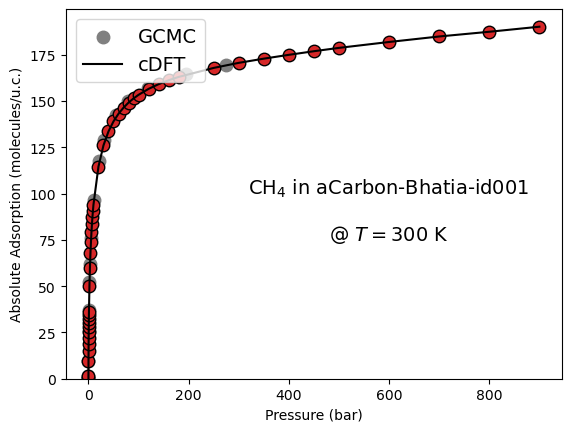

In [19]:
plt.rcParams["lines.markersize"] = 9

plt.scatter(gcmc_data['Pressure (bar)'],gcmc_data['Absolute adsorption (molecules/uc)'],marker='o',edgecolors='grey',facecolors='grey',label='GCMC')

plt.scatter(dft_data['Pressure (bar)'],dft_data['Absolute adsorption (molecules/uc)'],marker='o',edgecolors='k',facecolors='C3')
plt.plot(dft_data['Pressure (bar)'],dft_data['Absolute adsorption (molecules/uc)'],color='k',label='cDFT')

plt.legend(loc='upper left',fontsize=14)
plt.xlabel('Pressure (bar)')
plt.ylabel('Absolute Adsorption (molecules/u.c.)')
# plt.xlim(0.0,500)
plt.ylim(0.0,None)
plt.text(600,100,'CH$_4$ in '+structure_name,fontsize=14,
        horizontalalignment='center')
plt.text(600,75,fr'@ $T={kT:.0f}$ K',fontsize=14,
        horizontalalignment='center')

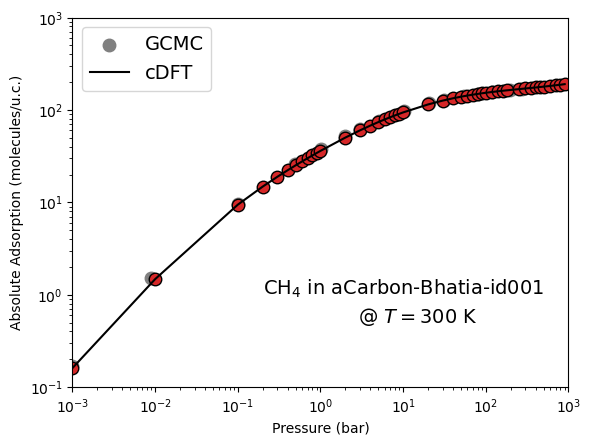

In [20]:
plt.scatter(gcmc_data['Pressure (bar)'],gcmc_data['Absolute adsorption (molecules/uc)'],marker='o',edgecolors='grey',facecolors='grey',label='GCMC')

plt.scatter(dft_data['Pressure (bar)'],dft_data['Absolute adsorption (molecules/uc)'],marker='o',edgecolors='k',facecolors='C3')
plt.plot(dft_data['Pressure (bar)'],dft_data['Absolute adsorption (molecules/uc)'],color='k',label='cDFT')

plt.legend(loc='upper left',fontsize=14)
plt.xlabel('Pressure (bar)')
plt.ylabel('Absolute Adsorption (molecules/u.c.)')
plt.xlim(0.001,1e3)
plt.ylim(0.1,1e3)
plt.text(10,1,'CH$_4$ in '+structure_name,fontsize=14,
        horizontalalignment='center')
plt.text(15,0.5,fr'@ $T={kT:.0f}$ K',fontsize=14,
        horizontalalignment='center')
plt.yscale('log')
plt.xscale('log')

In [21]:
rhobMC = system.calculate_rho_from_pbar(gcmc_data['Pressure (bar)'])

(0.0, 122.6959294016162)

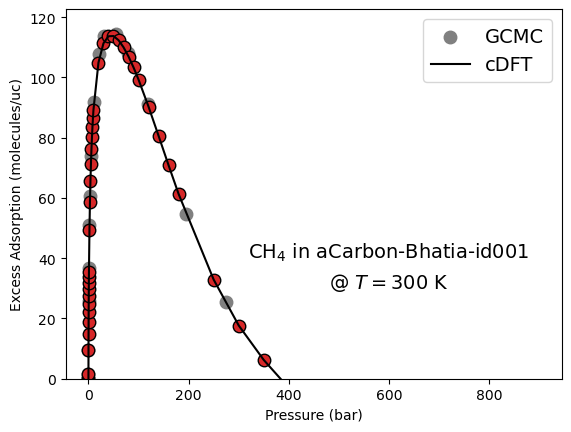

In [23]:
plt.scatter(gcmc_data['Pressure (bar)'],gcmc_data['Absolute adsorption (molecules/uc)']-rhobMC*system.helium_fraction*system.Vol,marker='o',edgecolors='grey',facecolors='grey',label='GCMC')

plt.scatter(dft_data['Pressure (bar)'],dft_data['Excess adsorption (molecules/uc)'],marker='o',edgecolors='k',facecolors='C3')
plt.plot(dft_data['Pressure (bar)'],dft_data['Excess adsorption (molecules/uc)'],color='k',label='cDFT')

plt.legend(loc='upper right',fontsize=14)
plt.xlabel('Pressure (bar)')
plt.ylabel('Excess Adsorption (molecules/uc)')

plt.text(600,40,'CH$_4$ in '+structure_name,fontsize=14,
        horizontalalignment='center')
plt.text(600,30,fr'@ $T={kT:.0f}$ K',fontsize=14,
        horizontalalignment='center')
# plt.xlim(0.0,800)
plt.ylim(0.0,None)